# Confusion Matrix and its Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
results_path = Path("../results")

print("Results folder ready.")

Results folder ready.


In [3]:
rf_model = joblib.load("../models/random_forest.pkl")

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [4]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (504160, 78)
y_test shape: (504160, 1)


In [5]:
label_mapping = pd.read_csv("../data/processed/label_mapping.csv")

print(label_mapping)

                Original_Label  Encoded_Label
0                       BENIGN              0
1                          Bot              1
2                         DDoS              2
3                DoS GoldenEye              3
4                     DoS Hulk              4
5             DoS Slowhttptest              5
6                DoS slowloris              6
7                  FTP-Patator              7
8                   Heartbleed              8
9                 Infiltration              9
10                    PortScan             10
11                 SSH-Patator             11
12    Web Attack � Brute Force             12
13  Web Attack � Sql Injection             13
14            Web Attack � XSS             14


In [6]:
class_names = label_mapping["Original_Label"].tolist()

print(class_names)

['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [7]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [8]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9969
Precision: 0.9982
Recall   : 0.9969
F1-score : 0.9974


In [9]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.29      0.99      0.45       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      1.00      0.99      2057
                  DoS Hulk       0.99      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.75      0.71      0.73       294
Web Attack � Sql Injection       1.00      0.25

In [10]:
with open("../results/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[417637    949     13     12    172      9      5      1      0      0
     198      1      3      0     12]
 [     5    385      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     0      0  25601      0      2      0      0      0      0      0
       0      0      0      0      0]
 [     3      0      0   2048      6      0      0      0      0      0
       0      0      0      0      0]
 [     6      0      0      5  34556      0      0      0      0      0
       2      0      0      0      0]
 [     0      0      0      0      0   1042      4      0      0      0
       0      0      0      0      0]
 [     6      0      0      0      0      4   1066      0      0      0
       0      0      1      0      0]
 [     0      0      0      0      0      0      0   1185      0      0
       0      0      0      0      1]
 [     1      0      0      0      0      0      0      0      1      0
       0      0      0      0      0]
 [     0  

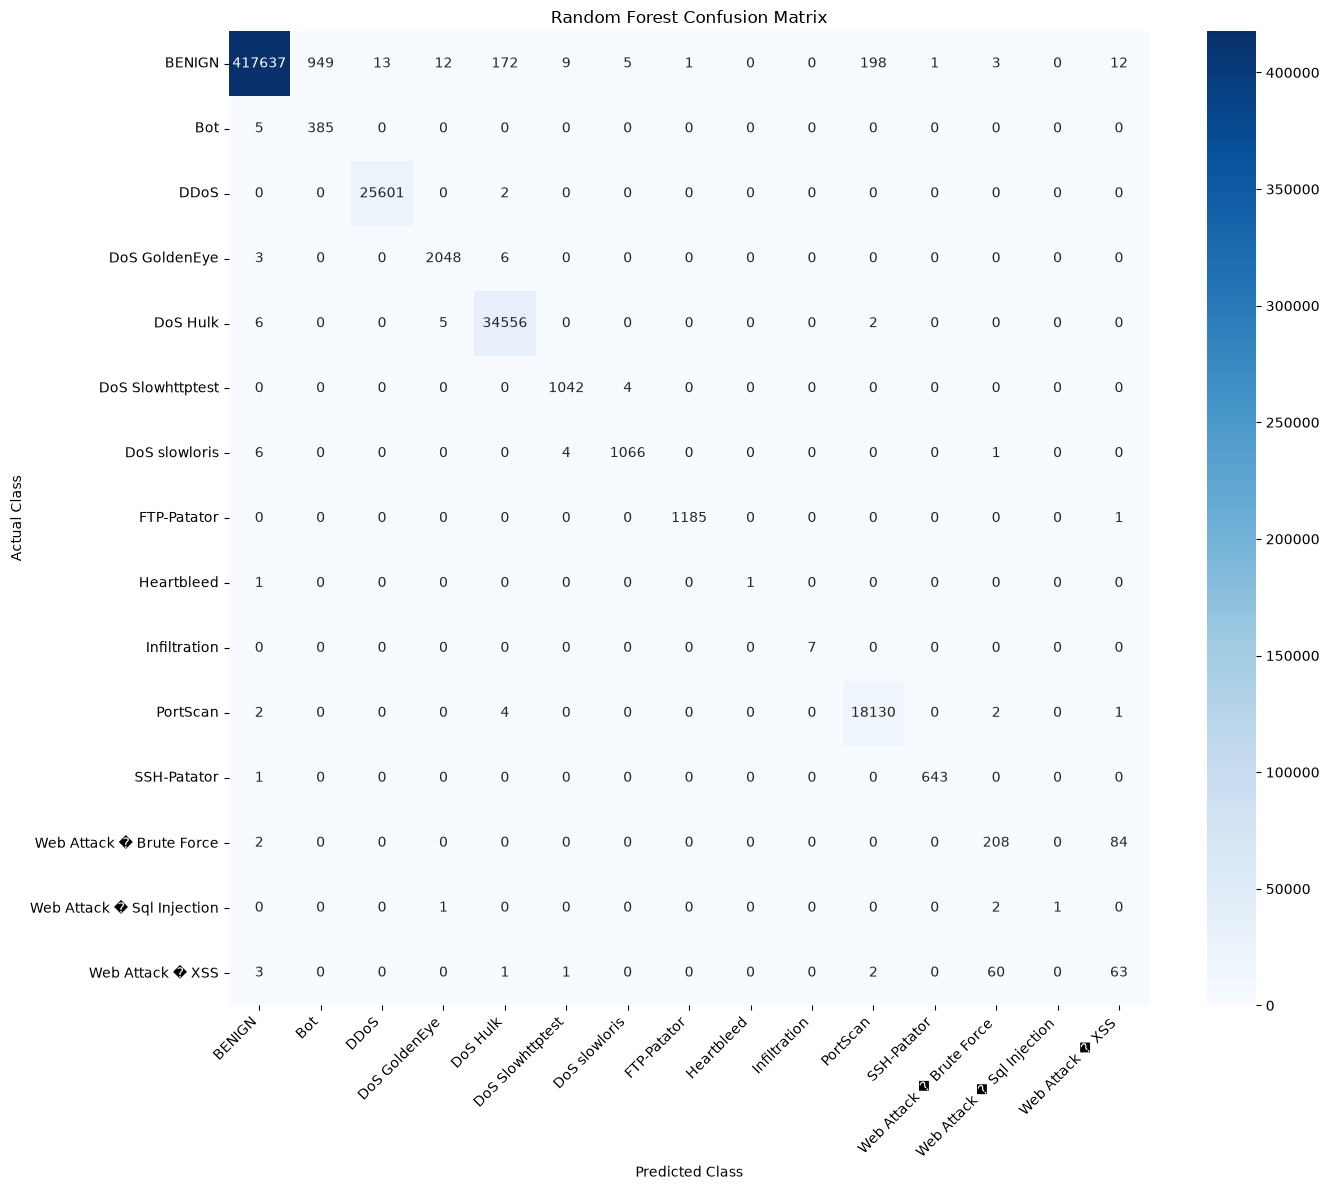

In [12]:
plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../results/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
results_df = pd.read_csv("../results/model_comparison.csv")

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.998092,0.998100,0.998092,0.998095
1,Random Forest,0.996852,0.998219,0.996852,0.997380
2,Logistic Regression,0.978029,0.980496,0.978029,0.978142


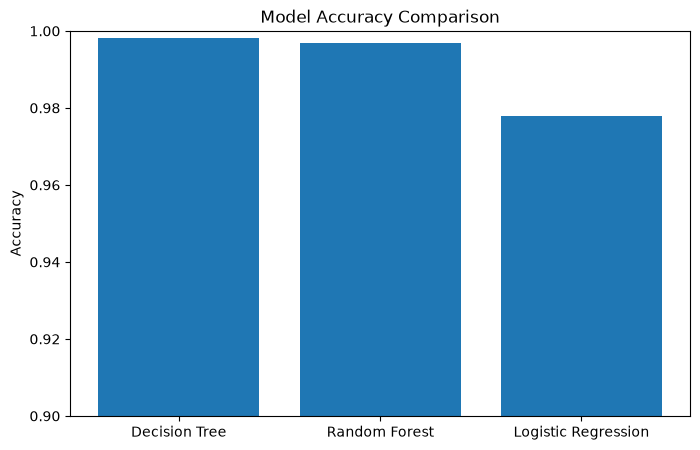

In [14]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

plt.savefig(
    "../results/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

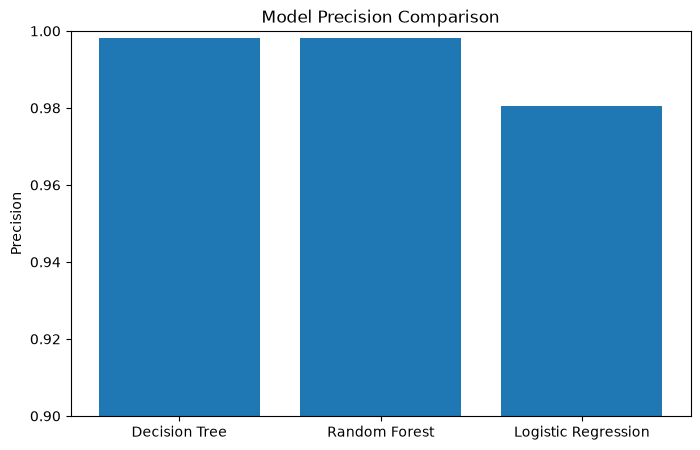

In [15]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Precision"])

plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0.9, 1.0)

plt.savefig(
    "../results/precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

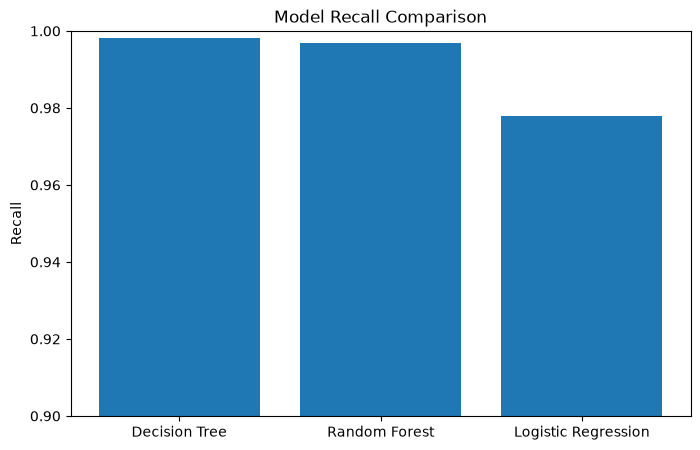

In [16]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Recall"])

plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0.9, 1.0)

plt.savefig(
    "../results/recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

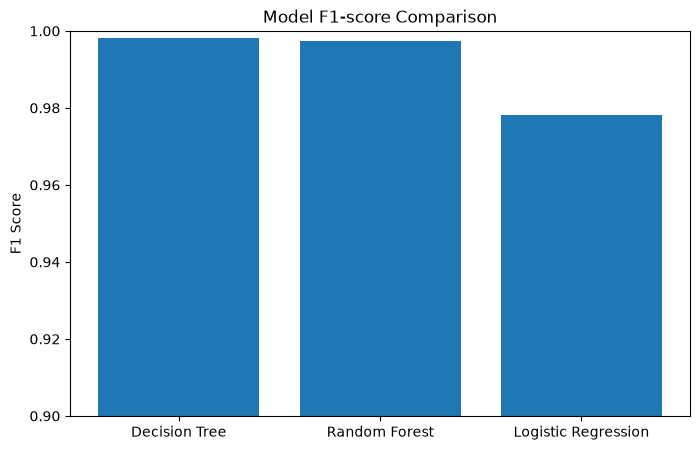

In [17]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model F1-score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.9, 1.0)

plt.savefig(
    "../results/f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()